# 📋 Descripción

Este cuaderno analiza qué indicadores relacionados con los deberes y los hábitos de estudio presentan mayor importancia predictiva para la media de Matemáticas de PISA 2022.

La nota esta calculada para los estratos del pais , los indicadores de deberes se agregan a esa misma unidad antes de unirlos y entrenar el modelo. El análisis describe asociaciones predictivas entre estratos, no efectos individuales ni relaciones causales.


<div style="
  background: linear-gradient(135deg, rgba(128, 128, 128, 0.25) 0%, rgba(64, 64, 64, 0.15) 100%);
  backdrop-filter: blur(4px);
  -webkit-backdrop-filter: blur(4px);
  border-left: 5px solid rgba(128, 128, 128, 0.6);
  padding: 16px;
  border-radius: 8px;
  color: inherit;
  margin: 20px 0;
">
  <strong style="display: block; margin-bottom: 6px; font-size: 1.1em;">
    💡 Uso de datos de 2022
  </strong>
    Dado que se esta realizando un análisis de la edición de PISA 2022, se usaran para esta parte las notas de matemáticas, correspondientes a la competencia específica de esta edición. Una vez completado el análisis de factores importantes para este año, se realizara una busqueda y adaptación de los indices correspondietes en los otros años
</div>


## Selección de variables

**Estudiantes (`pisa2022_estudiantes.parquet`)**

| Código de variable | Descripción y uso en el proyecto |
| :--- | :--- |
| `ST296Q01JA` | Tiempo dedicado a los deberes de Matemáticas; se convierte de categoría a horas aproximadas y se agrega por estrato. |
| `ST296Q04JA` | Tiempo total diario dedicado a los deberes; se convierte de categoría a horas aproximadas y se agrega por estrato. |
| `STUDYHMW` | Índice relacionado con la frecuencia de estudio y los deberes; se agrega por estrato. |
| `ST307Q07JA` | Indicador de dejar los deberes cuando son demasiado largos; se agrega por estrato. |
| `ST309Q05JA` | Indicador de revisar cuidadosamente los deberes antes de entregarlos; se agrega por estrato. |
| `W_FSTUWT` | Peso final del alumno, usado para agregar los indicadores de estudiantes por `CNT` y `STRATUM`. |
| `CNT`, `STRATUM` | Identificadores de país y estrato que permiten agregar y unir las tablas. |

**Colegios (`pisa2022_colegios.parquet`)**

| Código de variable | Descripción y uso en el proyecto |
| :--- | :--- |
| `SC212Q01JA` | Disponibilidad de salas donde el alumnado puede hacer los deberes. |
| `SC212Q02JA` | Disponibilidad de personal del centro que ayuda con los deberes. |
| `SC212Q03JA` | Disponibilidad de ayuda por otros alumnos. |
| `SENWT` | Peso del colegio, usado para agregar sus indicadores dentro de `CNT` y `STRATUM`. |
| `CNT`, `STRATUM`, `CNTSCHID` | Identificadores de país, estrato y colegio, utilizados para comprobar la correspondencia entre estudiantes y centros. |

**Variable objetivo ya procesada (`medias_asignaturas_anual`)**

| Variable / fichero | Descripción y uso en este cuaderno |
| :--- | :--- |
| `media_math_estrato` | Media de Matemáticas por país y estrato, calculada previamente a partir de los valores plausibles. Aquí solo se lee desde Parquet; no se recalcula ni se vuelve a ponderar. |
| `pisa22_medias_math_estrato.parquet` | Fichero de `data/intermediate/medias_asignaturas_anual` que contiene `CNT`, `STRATUM` y `media_math_estrato`. |

**Tiempos de respuesta (no disponibles en los Parquet actuales)**

| Variables | Situación en los datos actuales |
| :--- | :--- |
| `ST296_TT`, `ST307_TT`, `ST309_TT` | No están incluidas en los Parquet de estudiantes utilizados; por ello, no se aplica el filtro de *rapid responders* del flujo anterior con SAS. |

## Carga de los datos 

In [94]:
import gc
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from src.utils_pisa import *

establecer_semilla(42)
pd.set_option('display.float_format', lambda valor: f'{valor:.2f}')


✅ Semillas del proyecto establecidas con éxito (seed=42).


In [84]:
# Generamos las rutas de los ficheros de datos
ruta_datos_raw = Path('../../data/raw')
ruta_datos_intermedios = Path('../../data/intermediate')
ruta_medias_asignaturas = ruta_datos_intermedios/'medias_asignaturas_anual'

ruta_estudiantes = ruta_datos_raw / 'pisa2022_estudiantes.parquet'
ruta_colegios = ruta_datos_raw / 'pisa2022_colegios.parquet'
ruta_media_matematicas = ruta_medias_asignaturas / 'pisa22_medias_math_estrato.parquet'


In [124]:
# Almacenamos las variables de interes para el análisis de deberes
claves_estrato = ['CNT', 'STRATUM']

indicadores_alumno = [
    'ST296Q01JA', 'ST296Q04JA', 'STUDYHMW', 'ST307Q07JA', 'ST309Q05JA'
]

indicadores_colegio = ['SC212Q01JA', 'SC212Q02JA', 'SC212Q03JA']

columnas_estudiantes = claves_estrato + indicadores_alumno + ['CNTSCHID','W_FSTUWT', 'SENWT']

columnas_colegios = claves_estrato + ['CNTSCHID'] + indicadores_colegio

In [125]:
# Se leen únicamente las columnas necesarias relacionadas con los deberes
df_estudiantes = pd.read_parquet(ruta_estudiantes, columns=columnas_estudiantes)
df_colegios = pd.read_parquet(ruta_colegios, columns=columnas_colegios)
df_media_matematicas = pd.read_parquet(ruta_media_matematicas)

columnas_esperadas_nota = claves_estrato + ['media_math_estrato']

print(f'Estudiantes: {len(df_estudiantes):,}')
print(f'Colegios: {len(df_colegios):,}')
print(f'Número de estratos: {len(df_media_matematicas):,}')
df_media_matematicas.head()


Estudiantes: 268,610
Colegios: 10,131
Número de estratos: 422


,CNT,STRATUM,media_math_estrato
0,AUS,AUS01,508.70
1,AUS,AUS02,479.18
2,AUS,AUS03,540.42
3,AUS,AUS04,495.91
4,AUS,AUS05,478.73


## Agregación de los indicadores de deberes a país-estrato

La media de Matemáticas por `CNT` y `STRATUM` ya está calculada y se carga directamente desde `pisa22_medias_math_estrato.parquet`; no se vuelven a procesar aquí los valores plausibles ni se recalcula la nota. La función `promedio_ponderado_indicadores_estrato` se utiliza exclusivamente para resumir los indicadores de deberes a esa misma unidad: respuestas de estudiantes con `W_FSTUWT` y respuestas de colegios con `SENWT`.


In [126]:
# Recodificación de las categorías de tiempo : <30m, 30m-1h, 1-2h, 2-3h, 3-4h, >4h.
mapeo_horas = {1: 0.25, 
               2: 0.75, 
               3: 1.50, 
               4: 2.50, 
               5: 3.50, 
               6: 4.50}

for columna in ['ST296Q01JA', 'ST296Q04JA']:
    df_estudiantes[columna] = df_estudiantes[columna].map(mapeo_horas)


In [135]:
# Calculamos el promedio ponderado con el peso de estudiante de los indices a evaluar de los estudiantes
df_indicadores_alumno = promedio_ponderado_indicadores_estrato(
    df_estudiantes[claves_estrato + indicadores_alumno+['W_FSTUWT']],
    indicadores_alumno,
    'W_FSTUWT',
    claves_estrato
)

df_indicadores_alumno.head()



,CNT,STRATUM,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA
0,AUS,AUS04,0.75,1.41,3.84,2.93,3.15
1,AUS,AUS06,0.88,1.74,4.95,2.89,3.16
2,AUS,AUS08,0.74,1.38,3.33,2.98,3.06
3,AUS,AUS05,0.73,1.24,3.38,2.99,3.10
4,AUS,AUS14,0.59,1.33,3.43,3.05,3.09


In [132]:
#Pasamos la columna de pesos de estudiante W_FSTUWT a la de colegios pare poder tener la ponderación 
claves_colegio = ['CNT', 'STRATUM', 'CNTSCHID']

pesos_estudiantes_colegio = (
    df_estudiantes
    .groupby(claves_colegio, as_index=False)
    .agg(W_FSTUWT=('W_FSTUWT', 'sum'))
)

df_colegios = df_colegios.merge(
    pesos_estudiantes_colegio,
    on=claves_colegio,
    how='left',
    validate='one_to_one',
)

In [133]:
df_indicadores_colegio = promedio_ponderado_indicadores_estrato(
    df_colegios,
    indicadores_colegio,
    'W_FSTUWT',
    claves_estrato
)

df_indicadores_colegio.head()


,CNT,STRATUM,SC212Q01JA,SC212Q02JA,SC212Q03JA
0,AUS,AUS11,1.15,1.06,1.56
1,AUS,AUS15,1.26,1.17,1.63
2,AUS,AUS18,1.08,1.00,1.50
3,AUS,AUS03,1.01,1.01,1.22
4,AUS,AUS12,1.03,1.00,1.46


In [136]:
# Peso poblacional del estrato para ponderar su contribuci?n al modelo

# Agregamos el peso de senado 
peso_senado_alumno = (
    df_estudiantes[claves_estrato+['SENWT']]
    .groupby(claves_estrato, as_index=False)
    .agg(SENWT=('SENWT', 'mean')) # Usamos 'mean' para no distorsionar la escala del peso de senado por estrato
)

df_analisis_deberes = (
    df_media_matematicas
    .merge(df_indicadores_alumno, on=claves_estrato, how='left', validate='one_to_one')
    .merge(df_indicadores_colegio, on=claves_estrato, how='left', validate='one_to_one')
    .merge(peso_senado_alumno, on=claves_estrato, how='left', validate='one_to_one')
)

print(f"Filas de analisis-estratos): {len(df_analisis_deberes):,}")
print(f"Columnas de predictores: {len(indicadores_alumno) + len(indicadores_colegio)}")
df_analisis_deberes.head()


Filas de analisis-estratos): 422
Columnas de predictores: 8


,CNT,STRATUM,media_math_estrato,ST296Q01JA,ST296Q04JA,STUDYHMW,ST307Q07JA,ST309Q05JA,SC212Q01JA,SC212Q02JA,SC212Q03JA,SENWT
0,AUS,AUS01,508.70,0.62,1.30,3.81,3.05,3.06,1.11,1.00,1.19,0.12
1,AUS,AUS02,479.18,0.71,1.58,3.63,3.09,3.06,1.16,1.10,1.48,0.10
2,AUS,AUS03,540.42,0.75,1.69,4.67,2.85,3.27,1.01,1.01,1.22,0.07
3,AUS,AUS04,495.91,0.75,1.41,3.84,2.93,3.15,1.16,1.15,1.54,0.42
4,AUS,AUS05,478.73,0.73,1.24,3.38,2.99,3.10,1.25,1.17,1.73,0.52


In [137]:
porcentaje_nulos = (
    df_analisis_deberes[indicadores_alumno + indicadores_colegio]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename('porcentaje_nulos')
    .to_frame()
)
porcentaje_nulos


,porcentaje_nulos
ST309Q05JA,6.64
ST307Q07JA,6.40
ST296Q04JA,1.66
ST296Q01JA,1.66
STUDYHMW,1.66
SC212Q01JA,1.66
SC212Q02JA,1.66
SC212Q03JA,1.66


## Modelo de regresión basado en árboles

El modelo recibe una fila por país-estrato. Su variable objetivo es `media_math_estrato`, recuperada del Parquet de medias ya calculadas; los predictores son los indicadores de deberes agregados a ese nivel. La suma de `W_FSTUWT` por estrato pondera su contribución al ajuste. Las importancias describen asociaciones predictivas entre estratos, no efectos causales ni relaciones a nivel individual.

In [138]:
features = df_analisis_deberes[indicadores_alumno + indicadores_colegio]
target = df_analisis_deberes['media_math_estrato']
pesos = df_analisis_deberes['SENWT']

modelo_deberes = xgb.XGBRegressor(
    n_estimators=100,
    tree_method='hist',
    importance_type='gain',
)
modelo_deberes.fit(features, target, sample_weight=pesos)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type='gain', interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [139]:
tabla_importancia = pd.DataFrame({
    'Indicador': features.columns,
    'Importancia relativa (%)': modelo_deberes.feature_importances_ * 100,
}).sort_values('Importancia relativa (%)', ascending=False).reset_index(drop=True)

tabla_importancia


,Indicador,Importancia relativa (%)
0,STUDYHMW,18.27
1,ST309Q05JA,14.95
2,ST296Q04JA,13.90
3,SC212Q01JA,13.39
4,ST296Q01JA,13.07
5,SC212Q03JA,10.88
6,SC212Q02JA,8.99
7,ST307Q07JA,6.55


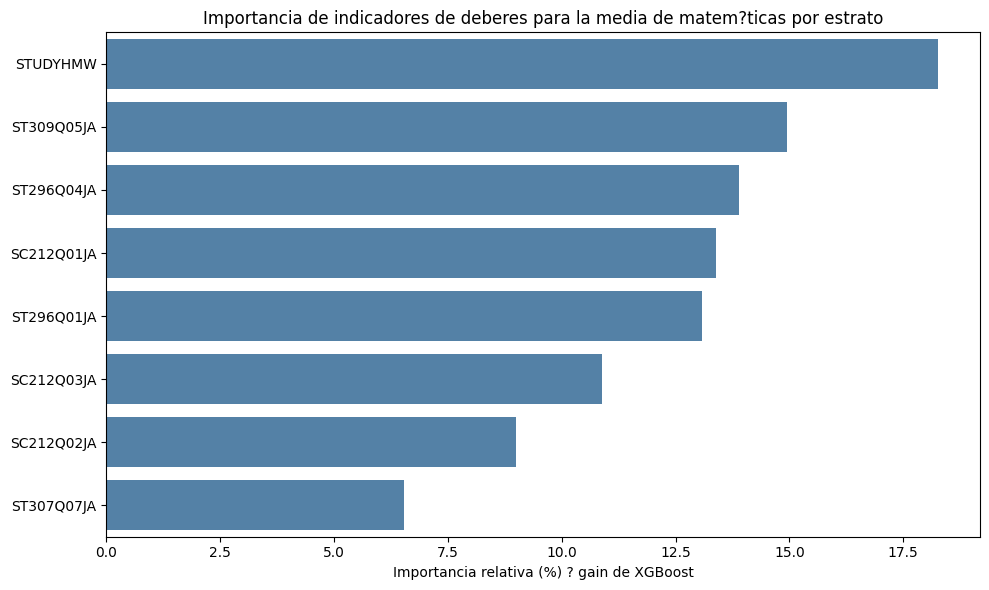

In [140]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tabla_importancia,
    x='Importancia relativa (%)',
    y='Indicador',
    color='steelblue',
)
plt.title('Importancia de indicadores de deberes para la media de matem?ticas por estrato')
plt.xlabel('Importancia relativa (%) ? gain de XGBoost')
plt.ylabel('')
plt.tight_layout()
plt.show()


In [ ]:
# Diccionario de traducción de los indicadores
diccionario_indicadores = {
    'ST296Q01JA': 'Horas de deberes de Matemáticas',
    'ST296Q04JA': 'Horas totales de deberes',
    'STUDYHMW': 'Frecuencia de estudio y deberes',
    'ST307Q07JA': 'Deja los deberes si son demasiado largos',
    'ST309Q05JA': 'Revisa los deberes antes de entregarlos',
    'SC212Q01JA': 'Disponibilidad de salas de estudio',
    'SC212Q02JA': 'Disponibilidad de personal de apoyo',
    'SC212Q03JA': 'Disponibilidad de ayuda de otros alumnos',
}

tabla_importancia_traducida = tabla_importancia.copy()
tabla_importancia_traducida['Indicador'] = (
    tabla_importancia_traducida['Indicador'].map(diccionario_indicadores)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=tabla_importancia_traducida,
    x='Importancia relativa (%)',
    y='Indicador',
    color='steelblue',
)
plt.title('Importancia de los indicadores de deberes para la media de Matemáticas')
plt.xlabel('Importancia relativa (%) — gain de XGBoost')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Nota sobre la unidad de análisis

La nota no es individual: cada observación representa un país y un estrato. Por ello, las importancias deben interpretarse como relaciones entre medias de indicadores de deberes y medias de Matemáticas agregadas, no como el efecto de los deberes en la nota de cada alumno.

In [ ]:
# Liberamos las tablas de entrada y agregaciones intermedias; se conservan el modelo y su tabla de importancia.
del df_estudiantes, df_colegios, df_media_matematicas
del df_indicadores_alumno, df_indicadores_colegio, df_pesos_estrato
gc.collect()
